# model_ver08: 樹種GroupCVによる波数範囲比較 CNN ノートブック

このノートブックでは、`model_ver05` の CNN 構成をできるだけ保ったまま、入力に使う波数範囲を変えて比較します。  
train と test で樹種が異なるため、未知樹種への汎化を見る目的で `樹種` 単位の GroupKFold を使います。

## このノートブックの狙い
- `model_ver05` と近い形で、波数範囲だけを変えた CNN を比較する
- full / no_edges / water_broad / water_1 / water_2 の 5 範囲を樹種GroupCVで評価する
- 最良範囲の OOF、test 予測、提出ファイルを保存する

## 入力の考え方
- 1 チャネル目: 選択した波数範囲の生スペクトル
- 2 チャネル目: 選択した波数範囲の Savitzky-Golay 平滑化後 1 次微分スペクトル


## 各関数・クラスの役割

- `CFG`  
  学習条件、fold 数、SG フィルタ、比較する波数範囲などをまとめて管理します。
- `select_spectral_columns_by_range`  
  指定した波数範囲に入るスペクトル列だけを取り出します。
- `compute_savgol_first_derivative`  
  Savitzky-Golay フィルタで平滑化しながら 1 次微分スペクトルを計算します。
- `build_multichannel_features`  
  生スペクトルと SG 後 1 次微分スペクトルを 2 チャネル配列にまとめます。
- `SpectralDataset` / `SpectralCNN`  
  `model_ver05` と同じ考え方の Dataset と 1 次元 CNN です。
- `run_group_cv`  
  1 つの波数範囲について樹種単位の GroupKFold で学習・OOF 予測・test 予測を実行します。
- `run_wave_range_experiments`  
  5 つの波数範囲を順番に評価し、最良範囲の提出ファイルを保存します。


In [1]:
# ============================================================
# ライブラリのインポートと設定値の定義
# ============================================================
import os
import gc
import random
from copy import deepcopy
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy.signal import savgol_filter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


class CFG:
    # バージョン名。出力ファイル名にも使う
    VER = 8

    # 乱数 seed
    seed = 42

    # パス設定
    ROOT = Path('/workspace')
    DATA_PATH = ROOT / 'data' / 'raw'
    MODEL_PATH = ROOT / 'models'
    SUBMISSION_PATH = ROOT / 'submission'

    # コンペ設定
    target_col = '含水率'
    # train と test で樹種が異なるため、未知樹種を想定して樹種単位で検証する
    group_col = '樹種'
    drop_cols = ['sample number', 'species number', '樹種', '含水率']
    n_splits = 5

    # 比較する波数範囲。値は (high, low) の順で書く
    # full は実データの下端 3999.82139 cm^-1 を含めるため、low を少し広げる
    wave_ranges = {
        'full': (10000, 3999),
        'no_edges': (9000, 4500),
        'water_broad': (7500, 4800),
        'water_1': (7500, 6500),
        'water_2': (5600, 4800),
    }

    # 学習設定。model_ver05 と比較しやすいように基本設定は揃える
    batch_size = 64
    num_workers = 0
    epochs = 40
    patience = 8
    learning_rate = 1e-3
    weight_decay = 1e-4

    # モデル設定
    in_channels = 2
    dropout = 0.20

    # Savitzky-Golay フィルタ設定
    sg_window_length = 11
    sg_polyorder = 2


CFG.MODEL_PATH.mkdir(parents=True, exist_ok=True)
CFG.SUBMISSION_PATH.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    """乱数 seed をまとめて固定する関数。再現性の確保に使う。"""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用デバイス: {device}')


使用デバイス: cpu


In [2]:
# ============================================================
# データの読み込みと波数範囲選択用の関数
# ============================================================
train_df = pd.read_csv(CFG.DATA_PATH / 'train.csv', encoding='cp932')
test_df = pd.read_csv(CFG.DATA_PATH / 'test.csv', encoding='cp932')
sample_submit_df = pd.read_csv(CFG.DATA_PATH / 'sample_submit.csv', header=None, encoding='cp932')


def get_spectral_columns(df: pd.DataFrame) -> List[str]:
    """目的変数や ID 列を除外し、スペクトル列だけを返す関数。"""
    return [col for col in df.columns if col not in CFG.drop_cols]


def select_spectral_columns_by_range(
    spectral_cols: List[str],
    high: float,
    low: float,
) -> List[str]:
    """指定した波数範囲に入るスペクトル列だけを返す関数。"""
    selected_cols = [col for col in spectral_cols if low <= float(col) <= high]
    if not selected_cols:
        raise ValueError(f'指定範囲 high={high}, low={low} に含まれるスペクトル列がありません。')
    return selected_cols


def rmse_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """RMSE を計算する関数。コンペの評価指標に合わせる。"""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def validate_savgol_params(window_length: int, polyorder: int, signal_length: int) -> None:
    """Savitzky-Golay フィルタの設定が妥当か事前に確認する関数。"""
    if window_length % 2 == 0:
        raise ValueError('sg_window_length は奇数である必要があります。')
    if window_length <= polyorder:
        raise ValueError('sg_window_length は sg_polyorder より大きい必要があります。')
    if window_length > signal_length:
        raise ValueError('sg_window_length はスペクトル長以下である必要があります。')


def compute_savgol_first_derivative(
    x: np.ndarray,
    delta: float,
    window_length: int,
    polyorder: int,
) -> np.ndarray:
    """SG フィルタで平滑化しながら 1 次微分スペクトルを計算する関数。"""
    derivative = savgol_filter(
        x,
        window_length=window_length,
        polyorder=polyorder,
        deriv=1,
        delta=delta,
        axis=1,
        mode='interp',
    )
    return derivative.astype(np.float32)


def build_multichannel_features(raw_spectra: np.ndarray, wave_numbers: np.ndarray) -> np.ndarray:
    """生スペクトルと SG 後 1 次微分スペクトルを 2 チャネル特徴量にまとめる関数。"""
    signal_length = raw_spectra.shape[1]
    validate_savgol_params(CFG.sg_window_length, CFG.sg_polyorder, signal_length)

    # 波数列は降順なので、間隔の絶対値を使う
    delta = float(np.mean(np.abs(np.diff(wave_numbers))))
    derivative = compute_savgol_first_derivative(
        raw_spectra,
        delta=delta,
        window_length=CFG.sg_window_length,
        polyorder=CFG.sg_polyorder,
    )

    # 形状は (サンプル数, チャネル数, 波数数)
    features = np.stack([raw_spectra, derivative], axis=1)
    return features.astype(np.float32)



spectral_cols = get_spectral_columns(train_df)
y_train = train_df[CFG.target_col].values.astype(np.float32)
groups = train_df[CFG.group_col].values

n_groups = pd.Series(groups).nunique()
if CFG.n_splits > n_groups:
    raise ValueError(f'n_splits={CFG.n_splits} は group 数={n_groups} 以下にしてください。')

print(f'train shape: {train_df.shape}')
print(f'test shape: {test_df.shape}')
print(f'全スペクトル列数: {len(spectral_cols)}')
print(f'CV group column: {CFG.group_col}')
print(f'CV group 数: {n_groups}')

for range_name, (high, low) in CFG.wave_ranges.items():
    selected_cols = select_spectral_columns_by_range(spectral_cols, high=high, low=low)
    print(f'{range_name}: {high}-{low} cm^-1, columns={len(selected_cols)}')


train shape: (1322, 1559)
test shape: (550, 1558)
全スペクトル列数: 1555
CV group column: 樹種
CV group 数: 13
full: 10000-3999 cm^-1, columns=1555
no_edges: 9000-4500 cm^-1, columns=1167
water_broad: 7500-4800 cm^-1, columns=700
water_1: 7500-6500 cm^-1, columns=259
water_2: 5600-4800 cm^-1, columns=207


In [3]:
# ============================================================
# Dataset・Model・学習関数の定義
# ============================================================
def scale_multichannel_features(
    train_x: np.ndarray,
    valid_x: np.ndarray,
    test_x: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, list]:
    """チャネルごとに scaler を fit して標準化する関数。"""
    train_scaled = np.empty_like(train_x)
    valid_scaled = np.empty_like(valid_x)
    test_scaled = np.empty_like(test_x)
    scalers = []

    for channel_idx in range(train_x.shape[1]):
        scaler = StandardScaler()
        train_scaled[:, channel_idx, :] = scaler.fit_transform(train_x[:, channel_idx, :])
        valid_scaled[:, channel_idx, :] = scaler.transform(valid_x[:, channel_idx, :])
        test_scaled[:, channel_idx, :] = scaler.transform(test_x[:, channel_idx, :])
        scalers.append(scaler)

    return train_scaled, valid_scaled, test_scaled, scalers


class SpectralDataset(Dataset):
    """多チャネルスペクトル配列と目的変数を PyTorch 用に受け渡す Dataset。"""

    def __init__(self, x: np.ndarray, y: np.ndarray | None = None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y[:, None], dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, idx: int):
        if self.y is None:
            return self.x[idx]
        return self.x[idx], self.y[idx]


class ConvBlock(nn.Module):
    """畳み込み + BatchNorm + ReLU をまとめた再利用用ブロック。"""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 7):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class SpectralCNN(nn.Module):
    """生スペクトル + SG 後 1 次微分スペクトルの 2 チャネル入力を扱う 1 次元 CNN。"""

    def __init__(self, in_channels: int = 2, dropout: float = 0.2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 32, kernel_size=9),
            ConvBlock(32, 64, kernel_size=7),
            ConvBlock(64, 128, kernel_size=5),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
) -> float:
    """1 エポック分だけ学習し、平均損失を返す。"""
    model.train()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)


def valid_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> Tuple[float, float, np.ndarray]:
    """検証データで損失と RMSE を計算し、予測値も返す。"""
    model.eval()
    total_loss = 0.0
    preds_list = []
    target_list = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * x_batch.size(0)

            preds_list.append(preds.detach().cpu().numpy().reshape(-1))
            target_list.append(y_batch.detach().cpu().numpy().reshape(-1))

    preds_np = np.concatenate(preds_list)
    targets_np = np.concatenate(target_list)
    avg_loss = total_loss / len(loader.dataset)
    rmse = rmse_score(targets_np, preds_np)
    return avg_loss, rmse, preds_np


def predict_with_model(model: nn.Module, loader: DataLoader) -> np.ndarray:
    """1 つの学習済みモデルで推論し、予測値を配列で返す。"""
    model.eval()
    preds_list = []

    with torch.no_grad():
        for x_batch in loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            preds_list.append(preds.detach().cpu().numpy().reshape(-1))

    return np.concatenate(preds_list)


In [4]:
# ============================================================
# GroupKFold による学習と OOF 予測
# ============================================================
def run_group_cv(
    x: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    x_test: np.ndarray,
    range_name: str,
) -> Tuple[np.ndarray, np.ndarray, list]:
    """
    樹種単位で GroupKFold を行い、未知樹種への汎化を見積もる。
    各 fold の最良モデル・OOF 予測・テスト予測平均を返す関数。
    """
    splitter = GroupKFold(n_splits=CFG.n_splits)

    oof_preds = np.zeros(len(x), dtype=np.float32)
    test_preds = np.zeros(len(x_test), dtype=np.float32)
    history = []

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(x, y, groups), start=1):
        print('=' * 70)
        print(f'Range: {range_name} | Fold {fold}/{CFG.n_splits}')
        valid_groups = sorted(pd.Series(groups[valid_idx]).unique())
        print(f'Valid {CFG.group_col}: {valid_groups}')

        x_train_fold, x_valid_fold, x_test_fold, _ = scale_multichannel_features(
            x[train_idx],
            x[valid_idx],
            x_test,
        )

        train_dataset = SpectralDataset(x_train_fold, y[train_idx])
        valid_dataset = SpectralDataset(x_valid_fold, y[valid_idx])
        test_dataset = SpectralDataset(x_test_fold)

        train_loader = DataLoader(
            train_dataset,
            batch_size=CFG.batch_size,
            shuffle=True,
            num_workers=CFG.num_workers,
            pin_memory=torch.cuda.is_available(),
        )
        valid_loader = DataLoader(
            valid_dataset,
            batch_size=CFG.batch_size,
            shuffle=False,
            num_workers=CFG.num_workers,
            pin_memory=torch.cuda.is_available(),
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=CFG.batch_size,
            shuffle=False,
            num_workers=CFG.num_workers,
            pin_memory=torch.cuda.is_available(),
        )

        model = SpectralCNN(in_channels=CFG.in_channels, dropout=CFG.dropout).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=CFG.learning_rate,
            weight_decay=CFG.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=3,
        )

        best_rmse = np.inf
        best_state = None
        patience_counter = 0
        fold_log = []

        for epoch in range(1, CFG.epochs + 1):
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
            valid_loss, valid_rmse, _ = valid_one_epoch(model, valid_loader, criterion)
            scheduler.step(valid_rmse)

            current_lr = optimizer.param_groups[0]['lr']
            fold_log.append(
                {
                    'range_name': range_name,
                    'fold': fold,
                    'valid_groups': ','.join(map(str, valid_groups)),
                    'epoch': epoch,
                    'train_loss': train_loss,
                    'valid_loss': valid_loss,
                    'valid_rmse': valid_rmse,
                    'lr': current_lr,
                }
            )

            print(
                f'Epoch {epoch:02d} | '
                f'train_loss={train_loss:.4f} | '
                f'valid_loss={valid_loss:.4f} | '
                f'valid_rmse={valid_rmse:.4f} | '
                f'lr={current_lr:.6f}'
            )

            if valid_rmse < best_rmse:
                best_rmse = valid_rmse
                best_state = deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= CFG.patience:
                print(f'早期終了: {CFG.patience} エポック改善しなかったため終了します。')
                break

        model.load_state_dict(best_state)
        _, best_valid_rmse, valid_preds = valid_one_epoch(model, valid_loader, criterion)
        oof_preds[valid_idx] = valid_preds
        fold_test_preds = predict_with_model(model, test_loader)
        test_preds += fold_test_preds / CFG.n_splits

        model_save_path = CFG.MODEL_PATH / f'model_ver08_{range_name}_fold{fold}.pth'
        torch.save(model.state_dict(), model_save_path)
        print(f'Range {range_name} fold {fold} best RMSE: {best_valid_rmse:.4f}')
        print(f'モデル保存先: {model_save_path}')

        history.extend(fold_log)

        del train_dataset, valid_dataset, test_dataset
        del train_loader, valid_loader, test_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return oof_preds, test_preds, history


In [5]:
# ============================================================
# 波数範囲ごとの学習・OOF 評価・保存
# ============================================================
def save_submission(predictions: np.ndarray) -> Path:
    """サンプル提出ファイルの形式で予測値を書き出す関数。"""
    submit_df = sample_submit_df.copy()
    submit_df[1] = predictions
    save_path = CFG.SUBMISSION_PATH / 'model_ver08_submission.csv'
    submit_df.to_csv(save_path, header=False, index=False)
    return save_path


def build_range_features(range_name: str, high: float, low: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """指定した波数範囲の train/test 特徴量と波数配列を作成する関数。"""
    selected_cols = select_spectral_columns_by_range(spectral_cols, high=high, low=low)
    wave_numbers = np.array([float(col) for col in selected_cols], dtype=np.float32)

    raw_train = train_df[selected_cols].values.astype(np.float32)
    raw_test = test_df[selected_cols].values.astype(np.float32)

    x_train_raw = build_multichannel_features(raw_train, wave_numbers)
    x_test_raw = build_multichannel_features(raw_test, wave_numbers)

    print('=' * 70)
    print(f'Range: {range_name}')
    print(f'波数範囲: {high}-{low} cm^-1')
    print(f'スペクトル列数: {len(selected_cols)}')
    print(f'入力特徴量 shape: {x_train_raw.shape}')
    return x_train_raw, x_test_raw, wave_numbers


def run_wave_range_experiments() -> Tuple[pd.DataFrame, dict, pd.DataFrame]:
    """5 つの波数範囲を順番に評価し、最良範囲の結果を保存する関数。"""
    results = []
    all_history = []
    best_result = {
        'range_name': None,
        'cv_rmse': np.inf,
        'oof_preds': None,
        'test_preds': None,
    }

    for range_name, (high, low) in CFG.wave_ranges.items():
        x_train_raw, x_test_raw, _ = build_range_features(range_name, high=high, low=low)
        oof_preds, test_preds, history = run_group_cv(
            x=x_train_raw,
            y=y_train,
            groups=groups,
            x_test=x_test_raw,
            range_name=range_name,
        )

        cv_rmse = rmse_score(y_train, oof_preds)
        print('=' * 70)
        print(f'Range {range_name} Species Group CV RMSE: {cv_rmse:.4f}')

        oof_df = train_df[['sample number', 'species number', '樹種', '含水率']].copy()
        oof_df['oof_pred'] = oof_preds
        oof_df.to_csv(CFG.MODEL_PATH / f'model_ver08_oof_{range_name}.csv', index=False, encoding='utf-8-sig')

        pred_df = test_df[['sample number', 'species number', '樹種']].copy()
        pred_df['pred'] = test_preds
        pred_df.to_csv(CFG.MODEL_PATH / f'model_ver08_test_pred_{range_name}.csv', index=False, encoding='utf-8-sig')

        results.append(
            {
                'range_name': range_name,
                'high': high,
                'low': low,
                'n_features': x_train_raw.shape[-1],
                'cv_group_col': CFG.group_col,
                'cv_rmse': cv_rmse,
            }
        )
        all_history.extend(history)

        if cv_rmse < best_result['cv_rmse']:
            best_result.update(
                {
                    'range_name': range_name,
                    'cv_rmse': cv_rmse,
                    'oof_preds': oof_preds,
                    'test_preds': test_preds,
                }
            )

        del x_train_raw, x_test_raw
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    results_df = pd.DataFrame(results).sort_values('cv_rmse').reset_index(drop=True)
    history_df = pd.DataFrame(all_history)

    results_df.to_csv(CFG.MODEL_PATH / 'model_ver08_range_results.csv', index=False, encoding='utf-8-sig')
    history_df.to_csv(CFG.MODEL_PATH / 'model_ver08_history.csv', index=False, encoding='utf-8-sig')

    best_oof_df = train_df[['sample number', 'species number', '樹種', '含水率']].copy()
    best_oof_df['oof_pred'] = best_result['oof_preds']
    best_oof_df.to_csv(CFG.MODEL_PATH / 'model_ver08_oof_best.csv', index=False, encoding='utf-8-sig')

    best_pred_df = test_df[['sample number', 'species number', '樹種']].copy()
    best_pred_df['pred'] = best_result['test_preds']
    best_pred_df.to_csv(CFG.MODEL_PATH / 'model_ver08_test_pred_best.csv', index=False, encoding='utf-8-sig')

    submission_path = save_submission(best_result['test_preds'])
    print('=' * 70)
    print(f"Best range: {best_result['range_name']}")
    print(f"Best Species Group CV RMSE: {best_result['cv_rmse']:.4f}")
    print(f'提出ファイル保存先: {submission_path}')

    return results_df, best_result, history_df


results_df, best_result, history_df = run_wave_range_experiments()
display(results_df)


Range: full
波数範囲: 10000-3999 cm^-1
スペクトル列数: 1555
入力特徴量 shape: (1322, 2, 1555)
Range: full | Fold 1/5
Valid 樹種: ['チェリー', 'トチ']
Epoch 01 | train_loss=5258.5314 | valid_loss=2830.1667 | valid_rmse=53.1993 | lr=0.001000
Epoch 02 | train_loss=4526.4448 | valid_loss=2280.8202 | valid_rmse=47.7579 | lr=0.001000
Epoch 03 | train_loss=3282.4071 | valid_loss=975.4706 | valid_rmse=31.2325 | lr=0.001000
Epoch 04 | train_loss=1980.1732 | valid_loss=210.2727 | valid_rmse=14.5008 | lr=0.001000
Epoch 05 | train_loss=1269.7883 | valid_loss=207.9156 | valid_rmse=14.4193 | lr=0.001000
Epoch 06 | train_loss=1066.2909 | valid_loss=86.0981 | valid_rmse=9.2789 | lr=0.001000
Epoch 07 | train_loss=1080.2429 | valid_loss=180.7851 | valid_rmse=13.4456 | lr=0.001000
Epoch 08 | train_loss=1024.4308 | valid_loss=526.0514 | valid_rmse=22.9358 | lr=0.001000
Epoch 09 | train_loss=1001.6196 | valid_loss=190.2537 | valid_rmse=13.7932 | lr=0.001000
Epoch 10 | train_loss=845.1320 | valid_loss=160.8274 | valid_rmse=12.6818

,range_name,high,low,n_features,cv_group_col,cv_rmse
0,water_2,5600,4800,207,樹種,26.691518
1,full,10000,3999,1555,樹種,27.050039
2,water_broad,7500,4800,700,樹種,27.530062
3,no_edges,9000,4500,1167,樹種,27.849994
4,water_1,7500,6500,259,樹種,28.713593


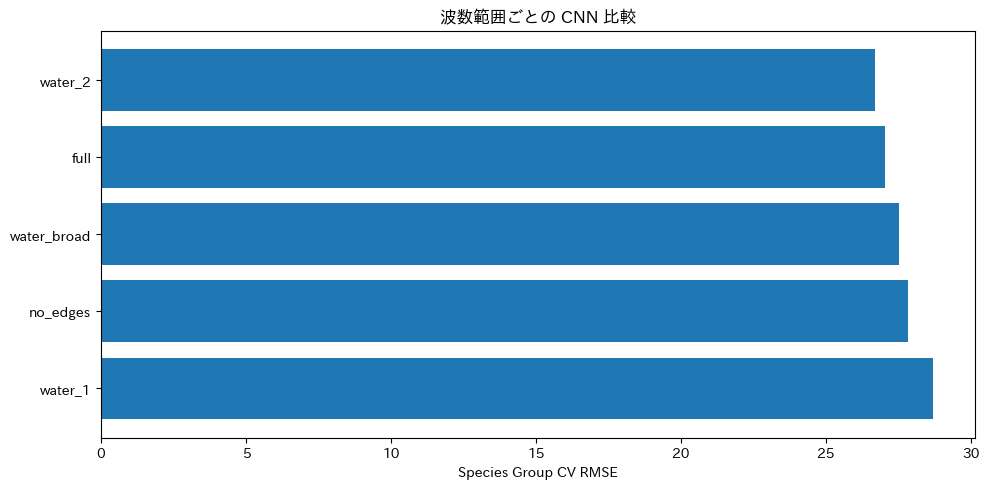

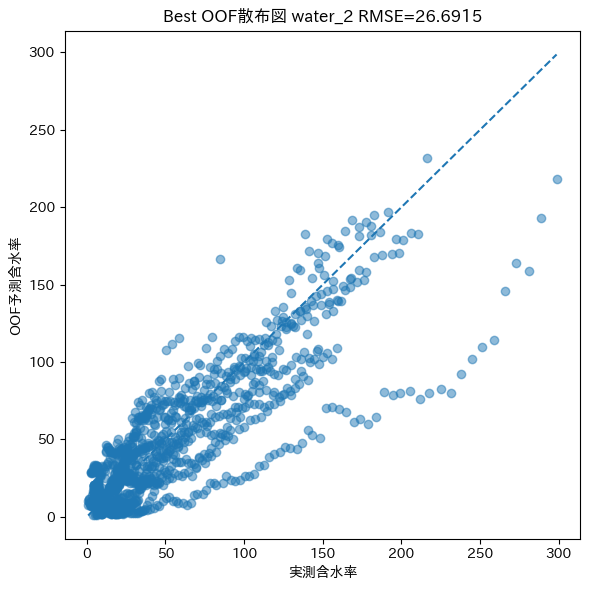

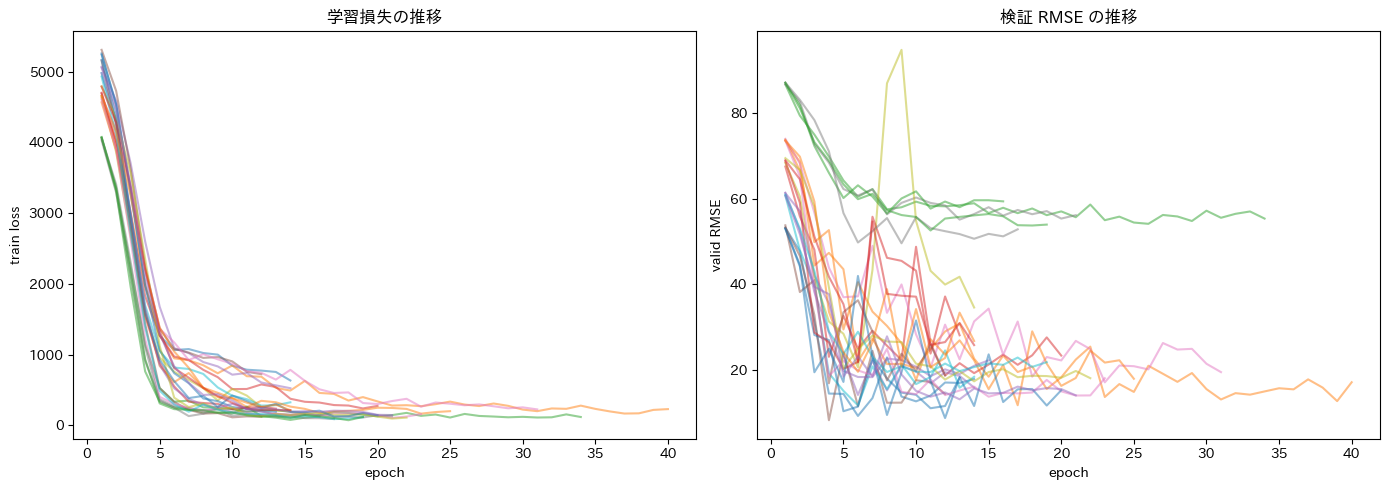

In [6]:
# ============================================================
# 学習結果の可視化
# ============================================================
plt.figure(figsize=(10, 5))
plot_df = results_df.sort_values('cv_rmse', ascending=True)
plt.barh(plot_df['range_name'], plot_df['cv_rmse'])
plt.gca().invert_yaxis()
plt.xlabel('Species Group CV RMSE')
plt.title('波数範囲ごとの CNN 比較')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_train, best_result['oof_preds'], alpha=0.5)
line_min = min(y_train.min(), best_result['oof_preds'].min())
line_max = max(y_train.max(), best_result['oof_preds'].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
plt.xlabel('実測含水率')
plt.ylabel('OOF予測含水率')
plt.title(f"Best OOF散布図 {best_result['range_name']} RMSE={best_result['cv_rmse']:.4f}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (range_name, fold), fold_df in history_df.groupby(['range_name', 'fold']):
    axes[0].plot(fold_df['epoch'], fold_df['train_loss'], alpha=0.5)
    axes[1].plot(fold_df['epoch'], fold_df['valid_rmse'], alpha=0.5)

axes[0].set_title('学習損失の推移')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('train loss')
axes[1].set_title('検証 RMSE の推移')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('valid RMSE')
plt.tight_layout()
plt.show()


## 補足

- `model_ver08` は `model_ver05` の CNN 構成を大きく変えず、入力に使う波数範囲だけを比較するノートブックです。
- 比較範囲は `full`, `no_edges`, `water_broad`, `water_1`, `water_2` の 5 つです。
- CV は `樹種` 単位の GroupKFold にしており、未知樹種への汎化を見ます。
- 各範囲の fold モデル、OOF、test 予測は `models/` に保存します。
- 最良範囲の提出ファイルは `submission/model_ver08_submission.csv` に保存します。
